# Spotify Lab: Vectors, Inner Products, and Similar Songs

**Name(s):** **Niecia(zma5zw), Naman(teb9th), Mason(hmr2xq), Asif(yrq8vu)**

You are a new data engineer at Spotify.

When a listener asks for songs with similar content, we want to query the library of music and select appropriate recommendations. 

Every song is represented as a vector, and we are using a **vector database**: Each song is encoded as a vector of word counts. So if "love" appears 12 times in the song, the "love" coordinate is $x_{\text{love}}=12$. If Metallica writes songs about topics that are more similar to Black Sabbath than to Josh Groban, then the vector representations of their songs will have more similar profiles, and we should suggest Black Sabbath over Josh Groban. This approach is fundamental to technologies like LLMs or facial recognition, which store documents and faces as vectors and conducts fast look-ups using the kinds of math we'll look at in this lab.

The main data, `song_vectors.csv.gz`, include:

- `track_id`, `song_id`, `artist_id`: Internal unique track identifiers
- `artist_name`, `song_title`, `release`: Artist, song, album
- `release_year`, `duration`: `
- `artist_familiarity`, `artist_hotttnesss`: Measures of ubiquity, popularity
- `genre`, `top_tags`: Information about the song type
- `n_words`, `nnz_words`, `l2_norm`: Number of total words in the song, number of non-zero word coordinates (i.e. number of unique words), and the word counts squared/summed/square-rooted.
- `is_test`: Train-test split identification
- 800 columns of word counts

The `top_40_songs_by_genre.csv` file contains the top 40 songs by genre -- rock, metal, pop, punk, country, r&b/soul, folk, hip hop, electronic, blues, jazz, reggae, latin, classical -- by "hotttness". We'll use these songs to benchmark.

The `vocabulary.csv` file includes the 800 words that form the vector space in which the songs are modeled.

Each song becomes a vector of lyric-word counts, and then we use vector operations to quantify "similarity".

The big goal of this lab is simple:

**Vectors and inner products and vector length are the core tools of modern retrieval systems.**

## Setup

We will use:

- `./data/song_vectors.csv.gz`: one row per song
- `./data/vocabulary.csv`: the word columns used in the song vectors

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


songs = pd.read_csv( "./data/song_vectors.csv.gz" )
vocab = pd.read_csv( "./data/vocabulary.csv" )
top_40 = pd.read_csv("./data/top_40_songs_by_genre.csv")

word_cols = vocab["word"].tolist() # Song count matrix
meta_cols = songs.columns.drop(word_cols).tolist() # Information about tracks

print('Number of songs, number of words:', songs.shape)
print( 'Song metadata fields:', meta_cols[:8])

Number of songs, number of words: (8000, 816)
Song metadata fields: ['track_id', 'song_id', 'artist_id', 'artist_name', 'song_title', 'release', 'release_year', 'duration']


In [2]:
songs[meta_cols].head()

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0
1,TRAAWOR128F92DF3C8,SOBJYXZ12A8AE45FF1,ARY80281187FB3E380,Sandi Thom,Wounded Hearts,The Pink & The Lily,2008,205.21751,0.655359,0.405031,blues,blues,287,103,39.698866,0
2,TRABNZS128F932C6E8,SOCOZZE12A813568F7,AROWOZ41187FB5B535,G. Love & Special Sauce,Willow Tree,Yeah_ It's That Easy,1997,206.57587,0.717235,0.548694,blues,blues; chill; alternative; rock; jazz,211,64,33.090784,0
3,TRABOIH128F9300B06,SOHYOTB12AF72AA1D7,AR94ZOI1187FB46BDA,Willie Dixon,That's My Baby,Very Best Of The Blues,1989,208.90077,0.579533,0.429834,blues,delta blues; BLUEZZZ; blues; freedom; Willie D...,164,76,27.477263,0
4,TRABYAR128F931B1A4,SOVKUOE12A58A8066E,AR7BMMV1187FB5B2D7,Robben Ford,Something For The Pain,Blue Moon,2002,298.37016,0.604820,0.383877,blues,blues; Robben Ford; vinnie colaiuta; jimmy earl,187,75,27.604347,0


## Part 1: Similarity Measures for Song Vectors

The word-count columns are coordinates. That means each song is a vector in a high-dimensional space.

We will work with the song-by-word matrix $X$, where each row is one song vector.

In [3]:
X = songs[word_cols].to_numpy(dtype=float)

query_idx = 0 # Let's query the first song
query = X[query_idx]

print( 'Track metadata: \n')
print(songs.loc[query_idx, meta_cols])

print( 'Track word counts: \n')
print( query )

Track metadata: 

track_id                                            TRAAPIV128F1493132
song_id                                             SOJHKYL12A6D4FA0AC
artist_id                                           AR56P361187B9AC4DB
artist_name                                                 Gary Moore
song_title                                        What Are We Here For
release                                          Dark Days In Paradise
release_year                                                      1997
duration                                                     345.93914
artist_familiarity                                            0.761362
artist_hotttnesss                                             0.467111
genre                                                            blues
top_tags              blues; classic rock; rock; hard rock; blues rock
n_words                                                            218
nnz_words                                                  

In [4]:
# Let's see the counts for nonzero words

nonzero = np.flatnonzero(query)

pd.DataFrame({
    "word": np.array(word_cols)[nonzero],
    "count": query[nonzero].astype(int)
}).sort_values("count", ascending=False).head(15)

,word,count
62,we,27
4,are,10
17,for,9
37,of,7
63,what,6
26,it,6
21,here,6
20,have,6
41,our,5
54,through,5


## Step 1: Dot Product

The dot product is our first similarity score:

$$
x \cdot y = \sum_{j=1}^m x_j y_j
$$

It gets large when two songs align count mass on the same words. 

It also tends to go up for longer songs or songs with larger total counts, which is a choice we'll have to think about.

In [5]:
# Compute the dot product between every song vector and the query vector.
dot_scores = X @ query
dot_results = songs[meta_cols].copy()
dot_results["dot"] = dot_scores
dot_results.sort_values("dot", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,dot
1582,TRFSCLD12903CD213F,SOENGNL12AB018E1BD,AR4L4WQ1187FB51996,The Prodigy,We Gonna Rock,What Evil Lurks,1991,282.30485,0.638614,0.601436,electronic,Rave; big beat; jungle; electronic; techno,312,10,141.703917,0,2136.0
6290,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,2115.0
5601,TRCETEN128F42AD6D0,SOXSRBF12D021B1340,AR4KTMS1187B9B4873,Bowling For Soup,Here We Go,Goes To The Movies,2004,188.36853,0.790406,0.561934,punk,pop punk; The Good Stuff; Bowling For Soup; pr...,374,92,98.863542,0,1939.0
1930,TRWAMJL128F92D124B,SOUSJHY12A8C1457F0,ARQ85IK11C8A415C6A,Ladyhawke,Crazy World,Ladyhawke,2008,214.93506,0.692569,0.554471,electronic,electropop; indie; female vocalists; electroni...,340,58,74.229374,0,1680.0
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,1656.0
3053,TRTCOWO128F930C444,SONWWDY12A6D4F7FB1,ARIHE7O1187FB47DED,The Streets,Weak Become Heroes,Summer Sessions,0,494.54975,0.772909,0.527872,hip hop,british; Hip-Hop; garage; 00s; hip hop,754,262,96.337947,0,1654.0
2971,TRPDBLM128E0792367,SOZRPOY12A8C1455F5,ARTDQRC1187FB4EFD4,Black Eyed Peas,Communication,Behind The Front,1998,344.00608,0.845602,1.005942,hip hop,Hip-Hop; funk; dance; communication; heisse sc...,592,173,80.068720,0,1615.0
2874,TRKRVKD128F9327008,SOXKVEZ12AB01821F5,ARX94AN1187FB4B54B,Hollywood Undead,Undead,Desperate Measures,2008,288.07791,0.703476,0.576626,hip hop,rapcore; hollywood undead; rap metal; rock; un...,831,222,97.082439,0,1476.0
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1397.0
5840,TRMGOLR128F933A7DB,SOYDERO12A6D4F72BC,ARZWK2R1187B98F09F,Rise Against,Survive,The Sufferer & The Witness,2006,221.46567,0.847082,0.625080,punk,punk rock; melodic hardcore; punk; rock; Rise ...,324,85,56.169387,0,1383.0


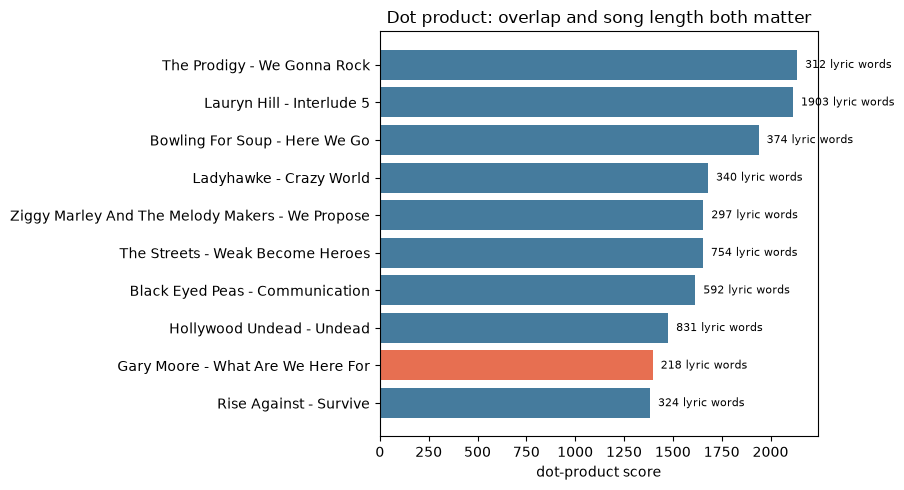

In [6]:
# Visual check: long songs can receive larger dot products.
top_dot = dot_results.sort_values("dot", ascending=False).head(10).copy()
top_dot["label"] = (
    top_dot["artist_name"].fillna("") + " - " + top_dot["song_title"].fillna("")
)
colors = ["#e76f51" if index == query_idx else "#457b9d" for index in top_dot.index]
plt.figure(figsize=(9, 5))
plt.barh(top_dot["label"], top_dot["dot"], color=colors)
for position, words in enumerate(top_dot["n_words"]):
    plt.text(top_dot["dot"].iloc[position], position, f"  {words:.0f} lyric words", va="center", fontsize=8)
plt.gca().invert_yaxis()
plt.xlabel("dot-product score")
plt.title("Dot product: overlap and song length both matter")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Look at the top matches. Do they seem similar because they use similar words, because they are genuinely similar songs, or because the dot product is partly rewarding song size?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the raw inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

>- **We think that this algorithm is rewarding both using similar words and also the song size. If two songs share only few words, but those words repeat a lot in each song, we would get a big dot product, meaning that our algorithm would show that the two songs are similar. For example, in the song "Interlude 5", the word "we" comes 33 times, and in the song "What are we Here for" the same word repeats 27 times. That alone produces a dot product of 891. Even if the two songs do not have a lot of other words in common, the word "we" has inflated the dot product a lot. This is not particular to only these two examples, the same thing happends in the top choices.**

In [7]:
dot1, dot2, dot3 = [], [], []

for i in top_40.index:
    song_id = top_40.loc[i, "song_id"] #Finding the song id with the index

    query_idx = songs.index[songs["song_id"] == song_id][0] #Finding the index of the song in the songs sheet with the index from top40 sheet
    query = X[query_idx]

    dot_scores = X @ query #Dot Product
    dot_scores[query_idx] = -np.inf #Self dot product

    top3_ids = np.argsort(dot_scores)[::-1][:3] #Sort in descending and getting top 3 values

    dot1.append(songs.loc[top3_ids[0], "genre"]) #adding to list
    dot2.append(songs.loc[top3_ids[1], "genre"])
    dot3.append(songs.loc[top3_ids[2], "genre"])

top_40["top1_genre_dot"] = dot1 #adding to sheet as new columns 
top_40["top2_genre_dot"] = dot2
top_40["top3_genre_dot"] = dot3

top_40.to_csv("data/top_40_songs_by_genre_results.csv", index=False) 

In [8]:
songs.index[songs["song_id"] == song_id]

RangeIndex(start=7795, stop=7796, step=1)

## Step 2: Centering and Covariance

Now we subtract each vector's own mean. This changes the question from "Do these songs use many of the same words?" to something closer to "Do these songs rise above and below their own average on the same words?"

In [9]:
query_centered = query - query.mean()
X_centered = X - X.mean(axis=1, keepdims=True)

centered_dot_scores = X_centered @ query_centered
covariance_scores = centered_dot_scores / X.shape[1]

cov_results = songs[meta_cols].copy()
cov_results["centered_dot"] = centered_dot_scores
cov_results["covariance"] = covariance_scores
cov_results.sort_values("covariance", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,centered_dot,covariance
6290,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,4783.12000,5.978900
2691,TRDPGXU128F9339C2A,SOELYON12AB01876A3,ARLHO5Z1187FB4C861,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Paul's Boutique (20th Anniversary Remastered E...,0,105.56036,0.853125,0.591628,hip hop,hip hop; leapsandbounds CDCollection,1746,505,153.652205,0,4767.60375,5.959505
2659,TRCHZXW128E079288A,SOMEJDK12D0219BB71,ARTH9041187FB43E1F,Eminem,8 Mile,8 Mile,2002,359.39220,0.886184,0.852677,hip hop,rap; Hip-Hop; Eminem; Soundtrack; hip hop,1141,328,132.992481,0,4094.49625,5.118120
3029,TRRSNPA128F148C45E,SOIUOEW12A67021D3D,AR8RXRI1187FB4104B,The Roots,Mellow My Man,From The Ground Up,0,288.31302,0.862795,0.600282,hip hop,Hip-Hop; jazzy; the roots; rap; hip hop,886,270,117.358425,0,3734.87625,4.668595
2763,TRGLNKG128F9307689,SOFVLYU12AB017F502,ARTH9041187FB43E1F,Eminem,My Darling,Relapse [Deluxe],2009,320.49587,0.871011,0.879237,hip hop,rap; detroit; Hip-Hop; Horrorcore; MOONH8SUN,1055,293,140.089257,0,3704.24125,4.630302
5245,TRLTYLK128F92FE6FF,SOWVIEO12AB0182D10,AR03BDP1187FB5B324,Britney Spears,Radar,Radar,2007,353.33179,0.947328,0.607257,pop,pop; dance; Britney Spears; female vocalists; ...,500,96,116.614750,0,3635.32375,4.544155
3125,TRWSYHO128F4282346,SOKHOQG12A8C13EBF2,ARSE5NP1187B9B98AB,Twista,I'm A Winner (Amended Album Version),The Day After,2005,260.23138,0.889614,0.593808,hip hop,rap; Hip-Hop; winner in bed twista,1253,166,218.622963,0,3594.83250,4.493541
2815,TRISBQQ128F93217A2,SOSKAYL12AB01884DE,ARPXABO1187FB4D15F,2Pac,Strictly 4 My N.I.G.G.A.Z.,Strictly 4 My N.I.G.G.A.Z.,0,355.47383,0.873187,0.517256,hip hop,Hip-Hop; hardcore rap; west coast hip-hop; lea...,921,288,104.316825,0,3565.21250,4.456516
2627,TRBEBJO128C719646B,SORXHBR12AF72A5DA5,ARCBD0U1187FB466EF,Nelly,Splurge,Nellyville,2002,309.49832,0.912369,0.787995,hip hop,Hip-Hop; rap; hip hop; rnb; 00s,911,225,131.289756,0,3550.71125,4.438389
6492,TROIJDA128F9341E70,SOCUXGX12A8C13B78C,ARLMXEA1187B9A7D04,R. Kelly,I Mean (I Don't Mean It),TP-2.com,2000,205.00853,0.811092,0.783843,r&b/soul,soul; rnb; english lyrics; SDZ,701,190,135.443715,0,3531.92375,4.414905


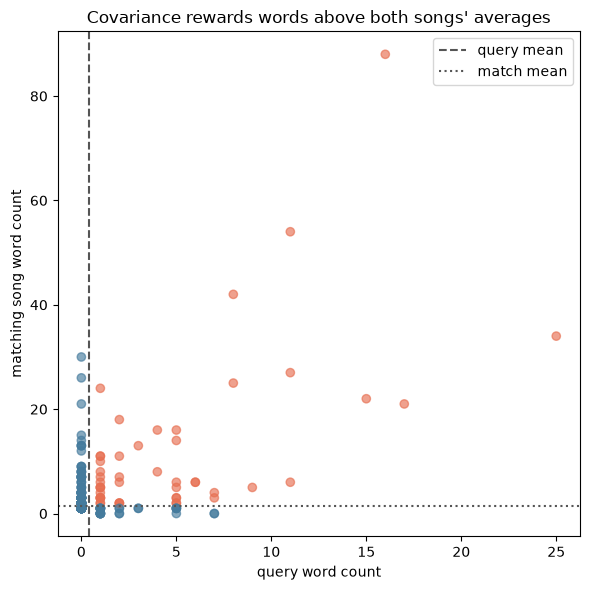

In [10]:
# Visual check: centering moves each song's average word count to zero.
comparison_idx = np.argsort(covariance_scores)[-2]
comparison = X[comparison_idx]
used_words = (query > 0) | (comparison > 0)
both_above_average = (query > query.mean()) & (comparison > comparison.mean())
plt.figure(figsize=(6, 6))
plt.scatter(query[used_words], comparison[used_words],
            c=np.where(both_above_average[used_words], "#e76f51", "#457b9d"), alpha=0.65)
plt.axvline(query.mean(), color="#555555", linestyle="--", label="query mean")
plt.axhline(comparison.mean(), color="#555555", linestyle=":", label="match mean")
plt.xlabel("query word count")
plt.ylabel("matching song word count")
plt.title("Covariance rewards words above both songs' averages")
plt.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Compare the rankings from dot product and covariance. What changed? Why does subtracting the mean change the notion of similarity?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the centered inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

>- **So the mean-centered dot product solves the issue that was created with the the simple dot product. The simple dot product rewards songs that have bigger word counts, or a specific word repeats numerous times. So the mean-centered dot product shifts thee attention from the absolute words counts to rewarding the pattern the songs share.**

In [11]:
cov1, cov2, cov3 = [], [], []

for i in top_40.index:
    song_id = top_40.loc[i, "song_id"]

    query_idx = songs.index[songs["song_id"] == song_id][0]
    query = X[query_idx]

    query_centered = query - query.mean()
    X_centered = X - X.mean(axis=1, keepdims=True)

    centered_dot_scores = X_centered @ query_centered
    centered_dot_scores[query_idx] = -np.inf
    
    covariance_scores = centered_dot_scores / X.shape[1]

    top3_by_cov = np.argsort(covariance_scores)[::-1][:3]

    cov1.append(songs.loc[top3_by_cov[0], "genre"])
    cov2.append(songs.loc[top3_by_cov[1], "genre"])
    cov3.append(songs.loc[top3_by_cov[2], "genre"])

top_40["top1_genre_cov"] = cov1
top_40["top2_genre_cov"] = cov2
top_40["top3_genre_cov"] = cov3

top_40.to_csv("data/top_40_songs_by_genre_results.csv", index=False)

## Step 3: Correlation

Correlation takes covariance and rescales by each vector's standard deviation. That means we now compare shared pattern after accounting for both average level and spread.

In [12]:
query_std = query.std()
X_std = X.std(axis=1)

denom = X_std * query_std
corr_scores = np.divide(
    covariance_scores,
    denom,
    out=np.zeros_like(covariance_scores),
    where=denom != 0,
)

corr_results = songs[meta_cols].copy()
corr_results["correlation"] = corr_scores
corr_results.sort_values("correlation", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,correlation
7779,TRQXNHC12903CD80BA,SOFKHCP12A8AE460AF,ARV4GYZ1187B9B8171,Violent Femmes,Add It Up,Permanent Record: The Very Best Of The Violent...,1983,284.34240,0.699073,0.522720,rock,alternative; 80s; rock; punk; indie,479,145,60.745370,0,0.694141
2815,TRISBQQ128F93217A2,SOSKAYL12AB01884DE,ARPXABO1187FB4D15F,2Pac,Strictly 4 My N.I.G.G.A.Z.,Strictly 4 My N.I.G.G.A.Z.,0,355.47383,0.873187,0.517256,hip hop,Hip-Hop; hardcore rap; west coast hip-hop; lea...,921,288,104.316825,0,0.692422
7358,TRBCRNY128F931D755,SOZHKRD12AB0185D84,ARKXXO11187FB4D9D9,Bad Cash Quartet,Valentine,Midnight Prayer,2003,175.62077,0.560999,0.399430,rock,indie; swedish; indie pop; indie rock; vocal,157,68,24.879711,0,0.682567
3129,TRWUNDW128F147093F,SOFZLVC12A6D4F9068,ARNHMFD1187FB3B3F6,LL Cool J,I Can't Live Without My Radio,Radio,1985,331.88526,0.749218,0.544322,hip hop,Hip-Hop; rap; 80s; LL Cool J; hip hop,745,248,81.829090,0,0.681100
2809,TRILLIR128F429E5D7,SOGGIPC12A8C142CD5,AR6F6I21187FB5A3AA,Aesop Rock,Battery,Labor Days,2001,307.04281,0.834539,0.477311,hip hop,Hip-Hop; underground hip-hop; rap; hip hop; De...,617,294,50.547008,0,0.680866
3112,TRWFXWM128F148D2D1,SORSMQE12A58A7A5FE,ARSQSCB1187B9912A0,Warren G,We Brings Heat,Take A Look Over Your Shoulder (Reality),1997,226.92526,0.718017,0.511683,hip hop,chillout; classic; hip hop; cool; Hip-Hop,548,238,50.517324,0,0.677367
3065,TRTMQWK128F4241384,SOIPJHX12A8C1324A3,ARSUQ9F1187B990561,Kottonmouth Kings,Bump,Greatest Highs,1998,232.51546,0.680868,0.563168,hip hop,Hip-Hop; stoned; BUMP; rapcore; kmk,795,259,74.276510,0,0.665229
2841,TRJPNAE128F425FAFB,SOZVCKM12A8C138484,ARRQWQW1187FB49844,King Tee,Act A Fool,Act A Fool,1988,258.82077,0.495739,0.372392,hip hop,Hip-Hop; rap; hip hop; West Coast Rap; west co...,624,251,66.730802,0,0.663739
7974,TRZCHKB128F92CB740,SOFCVMN12A8C141F62,AR4RBOB1187B9AC209,Anastacia,Club Megamix,Pieces Of A Dream,0,708.72771,0.583809,0.323554,rock,Slow Rock; pop; dance; party; female vocalist,749,201,98.020406,0,0.663071
4656,TRNMSBG128F422A877,SODFTRX12A6D4FBBFE,ARV8T9T1187B99F3F4,Amorphis,Weaving The Incantation,Silent Waters,2007,297.19465,0.709011,0.553566,metal,Melodic Death Metal; death metal; Progressive ...,140,77,19.646883,0,0.658409


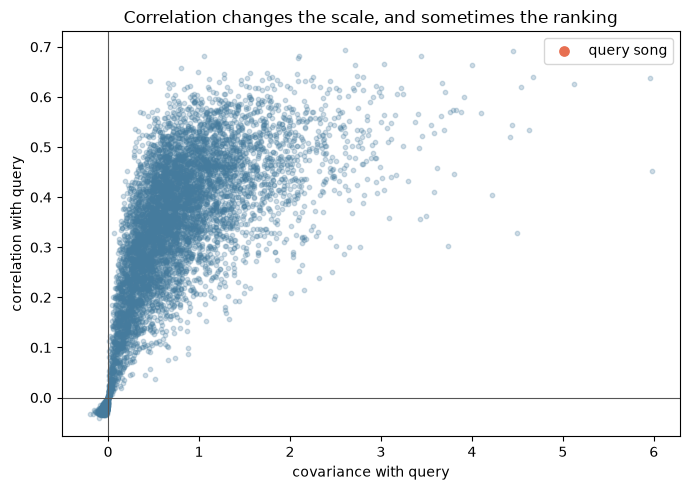

In [13]:
# Visual check: correlation rescales covariance by each song's spread.
plt.figure(figsize=(7, 5))
plt.scatter(covariance_scores, corr_scores, s=10, alpha=0.25, color="#457b9d")
plt.axhline(0, color="#555555", linewidth=0.8)
plt.axvline(0, color="#555555", linewidth=0.8)
plt.scatter(covariance_scores[query_idx], corr_scores[query_idx], color="#e76f51", s=45, label="query song")
plt.xlabel("covariance with query")
plt.ylabel("correlation with query")
plt.title("Correlation changes the scale, and sometimes the ranking")
plt.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Correlation and covariance are related, but not identical. What kind of song might move up in the ranking after standardization? What kind might move down?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the correlation. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

>- **When we computed song similarity based on the dot product of mean-centered vectors in Step 2, we reduced the affect of very large vectors that created a large dot product. However, a vector with a lot of variation between its values will become like a large vector after we mean-center it. For example, [1,2,600] will become [1/3,2/3,201] after mean-centering. This will produce a large dot product when it is dotted with the song we are analyzing. When we take covariance, we divide the dot product of both mean-centered vectors by n, and this reduces the effect of a highly-variable song vector. However, when we divide by the product of each vector's standard deviation, we completely control for variation within each vector.**

>- **Therefore, songs with a high degree of variability within their word count vectors are going to move down in ranking once we switch from covariance to correlation. Songs that are actually a good match with our target song are going to move up in ranking after we switch to correlation, because we have now controlled for the effect of word-count-variability as a driving factor in song matching.**

In [14]:
corr1, corr2, corr3 = [], [], []

for i in top_40.index:
    song_id = top_40.loc[i, "song_id"]

    query_idx = songs.index[songs["song_id"] == song_id][0]
    query = X[query_idx]

    query_centered = query - query.mean()
    X_centered = X - X.mean(axis=1, keepdims=True)

    centered_dot_scores = X_centered @ query_centered
    covariance_scores = centered_dot_scores / X.shape[1]

    query_std = query.std()
    X_std = X.std(axis=1)

    denom = X_std * query_std
    corr_scores = np.divide(
        covariance_scores,
        denom,
        out=np.zeros_like(covariance_scores),
        where=denom != 0,
)
    corr_scores[query_idx] = -np.inf 

    top3_by_corr = np.argsort(corr_scores)[::-1][:3]

    corr1.append(songs.loc[top3_by_corr[0], "genre"])
    corr2.append(songs.loc[top3_by_corr[1], "genre"])
    corr3.append(songs.loc[top3_by_corr[2], "genre"])

top_40["top1_genre_corr"] = corr1
top_40["top2_genre_corr"] = corr2
top_40["top3_genre_corr"] = corr3

top_40.to_csv("data/top_40_songs_by_genre_results.csv", index=False)

## Step 4: Cosine Similarity

Cosine similarity compares the raw vectors without centering around their means:

$$
\cos(\theta) = \frac{x \cdot y}{\|x\|\|y\|}
$$

In retrieval systems, this is often a better measure of content similarity than the raw dot product.

In [15]:
def cosine_scores(matrix, query_vector):
    numerators = matrix @ query_vector
    matrix_norms = np.linalg.norm(matrix, axis=1)
    query_norm = np.linalg.norm(query_vector)
    denominators = matrix_norms * query_norm
    return np.divide(
        numerators,
        denominators,
        out=np.zeros_like(numerators),
        where=denominators != 0,
    )


cos_scores = cosine_scores(X, query)

cosine_results = songs[meta_cols].copy()
cosine_results["cosine"] = cos_scores
cosine_results.sort_values("cosine", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,cosine
7795,TRRKJGZ128F148128F,SOAQCXS12D02191FC1,ART1UFU1187FB4C9B6,Hawk Nelson,Something On My Mind,Smile_ It's The End Of The World,2006,259.18649,0.738436,0.621970,rock,cross2life; alternative; favorites; christian;...,345,92,51.913389,0,1.000000
7779,TRQXNHC12903CD80BA,SOFKHCP12A8AE460AF,ARV4GYZ1187B9B8171,Violent Femmes,Add It Up,Permanent Record: The Very Best Of The Violent...,1983,284.34240,0.699073,0.522720,rock,alternative; 80s; rock; punk; indie,479,145,60.745370,0,0.708420
2815,TRISBQQ128F93217A2,SOSKAYL12AB01884DE,ARPXABO1187FB4D15F,2Pac,Strictly 4 My N.I.G.G.A.Z.,Strictly 4 My N.I.G.G.A.Z.,0,355.47383,0.873187,0.517256,hip hop,Hip-Hop; hardcore rap; west coast hip-hop; lea...,921,288,104.316825,0,0.707237
2809,TRILLIR128F429E5D7,SOGGIPC12A8C142CD5,AR6F6I21187FB5A3AA,Aesop Rock,Battery,Labor Days,2001,307.04281,0.834539,0.477311,hip hop,Hip-Hop; underground hip-hop; rap; hip hop; De...,617,294,50.547008,0,0.697772
3129,TRWUNDW128F147093F,SOFZLVC12A6D4F9068,ARNHMFD1187FB3B3F6,LL Cool J,I Can't Live Without My Radio,Radio,1985,331.88526,0.749218,0.544322,hip hop,Hip-Hop; rap; 80s; LL Cool J; hip hop,745,248,81.829090,0,0.696088
7358,TRBCRNY128F931D755,SOZHKRD12AB0185D84,ARKXXO11187FB4D9D9,Bad Cash Quartet,Valentine,Midnight Prayer,2003,175.62077,0.560999,0.399430,rock,indie; swedish; indie pop; indie rock; vocal,157,68,24.879711,0,0.696041
3112,TRWFXWM128F148D2D1,SORSMQE12A58A7A5FE,ARSQSCB1187B9912A0,Warren G,We Brings Heat,Take A Look Over Your Shoulder (Reality),1997,226.92526,0.718017,0.511683,hip hop,chillout; classic; hip hop; cool; Hip-Hop,548,238,50.517324,0,0.694369
3065,TRTMQWK128F4241384,SOIPJHX12A8C1324A3,ARSUQ9F1187B990561,Kottonmouth Kings,Bump,Greatest Highs,1998,232.51546,0.680868,0.563168,hip hop,Hip-Hop; stoned; BUMP; rapcore; kmk,795,259,74.276510,0,0.682323
2841,TRJPNAE128F425FAFB,SOZVCKM12A8C138484,ARRQWQW1187FB49844,King Tee,Act A Fool,Act A Fool,1988,258.82077,0.495739,0.372392,hip hop,Hip-Hop; rap; hip hop; West Coast Rap; west co...,624,251,66.730802,0,0.680961
7974,TRZCHKB128F92CB740,SOFCVMN12A8C141F62,AR4RBOB1187B9AC209,Anastacia,Club Megamix,Pieces Of A Dream,0,708.72771,0.583809,0.323554,rock,Slow Rock; pop; dance; party; female vocalist,749,201,98.020406,0,0.679759


<div class="alert alert-block alert-warning">

Compare the dot-product ranking to the cosine-similarity ranking. Which one seems more like a "similar songs" engine and which one seems more like a "shares lots of raw word mass" engine?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using cosine similarity. Before sorting, set the query song's score to `-np.inf`. Save your results as another column in "./data/top_40_songs_by_genre_results.csv".

</div>

>- **Once we calculate cosine similarity, we divide by the product of the two vector norms. This controls for the effect of vector size/magnitude/norm because and all we are left with after dividing by the product of norms is the angle relationship between the two vectors. The angle between the two vectors is a reliable measurement of their similarity.**


In [16]:
cosine1, cosine2, cosine3 = [], [], []

for i in top_40.index:
    song_id = top_40.loc[i, "song_id"]

    query_idx = songs.index[songs["song_id"] == song_id][0]
    query = X[query_idx]

    cos_scores = cosine_scores(X, query)

    cos_scores[query_idx] = -np.inf

    top3_by_cosine = np.argsort(cos_scores)[::-1][:3]

    cosine1.append(songs.loc[top3_by_cosine[0], "genre"])
    cosine2.append(songs.loc[top3_by_cosine[1], "genre"])
    cosine3.append(songs.loc[top3_by_cosine[2], "genre"])

top_40["top1_genre_cosine"] = cosine1
top_40["top2_genre_cosine"] = cosine2
top_40["top3_genre_cosine"] = cosine3

top_40.to_csv("data/top_40_songs_by_genre_results.csv", index=False)

<div class="alert alert-block alert-warning">

For the Top 40 songs, do you notice any patterns across the inner product, correlation, and cosine similarity top three recommendations you provided? Is there significant agreement, or do the recommendations change significantly by method?

Which methods are most in agreement?

Which methods do you think give the best results?

</div>

>- **Inner product is the most basic way of doing a recommender model. It basically calculates the number of words, however cosine variability and correlation would solve that problem by normalizing and compressing the vectors. Correlation can ignore meaningful differences in the overall baseline and that is where cosine similarity comes in play.**

>- **Which methods are most in agreement? Cosine similarity and correlation**

>- **Which methods do you think give the best results? Cosine similarity and correlation**

## Step 5:

Some words are "outliers": They appear in many songs with overwhelming frequency. For example, "love" is a common word in songs. That will boost the inner product significantly. Conversely, rare words like "amortization" or "zebra" might be rare and important for matching, but receive the same weight as a generic word like "about".

There is a useful technology to deal with this. We're going to cover one way of implementing it.

- Step 1: Compute the **term frequency** of each song-word pair, by taking $\log(1+x_{song,word})$. This is a matrix, $TF$. This transformation reduces the marginal importance of common words.
- Step 2: Compute the **inverse document frequency** of each word. Let $N$ be the number of documents. Let $df_w$ be the document frequency of word $w$, the num of documents in which word $w$ appears. Then $IDF_w = \log( N / df_w)$.

The **TF-IDF** matrix reweights the $TF$ matrix by the $IDF$ vector: $TFIDF = TF 	imes IDF$. This transformed matrix is then used for retrieval calculations (raw inner product, centered inner product, correlation, cosine similarity), instead of the raw word counts.

In [17]:
# Term frequency: repeated uses of one word count less and less.
TF = np.log1p(X) # Compute TF

# Document frequency: how many songs use each word at least once.
N = X.shape[0] # Determine number of documents
df = (X > 0).sum(axis=0) # Compute document frequency
IDF = np.log(N / df) # Compute IDF

# IDF is one number per word, so NumPy broadcasts it across every song row.
TFIDF = TF * IDF

print(pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=True).head(10))

print( pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=False).head(10) )


     word  document_frequency       idf
324     i                5966  0.293365
22    and                5960  0.294371
795   you                5671  0.344076
409    me                5420  0.389346
331    in                5345  0.403280
334    is                5191  0.432515
336    it                5045  0.461044
466   not                4961  0.477834
475    of                4785  0.513956
662  that                4597  0.554038
     word  document_frequency       idf
176   doo                  26  5.729100
258  funk                  48  5.115996
726   ven                  56  4.961845
327   ihr                  59  4.909659
770   wir                  60  4.892852
201    er                  63  4.844062
711     u                  66  4.797542
162  dich                  68  4.767689
596   sie                  78  4.630488
208    eu                  81  4.592748


<div class="alert alert-block alert-warning">

Do you notice any patterns among the lowest and highest IDF words?

Rerun your results from the previous steps to use raw inner product, centered inner product, correlation, and cosine similarity to generate new top 3 **non-self** recommendations for the top 40 songs.

How do the new TF-IDF-based recommendations compare to one another and the original recommendations?

</div>

>- **Words with lowest IDF scores appears in almost every or all songs. Those are words like "the" "is" "a" "and". However, words with highest IDFs appear only in one or few songs.**

>- **With TF_IDF we are basically looking for words that appear a lot in one song and does not appear so many times in the other songs. So It is looking for words that are unique to a particular song. However, any common word, like "we" would have a big effect in the inner dot product. Covariance and correlation would solve the issue of length, but the issue of ignoring the common words can only be solved with TF_IDF.**

In [19]:
top_40 = pd.read_csv("./data/top_40_songs_by_genre.csv")
X = TFIDF
dot1, dot2, dot3, cov1, cov2, cov3, corr1, corr2, corr3, cosine1, cosine2, cosine3 = [], [], [], [], [], [], [], [], [], [], [], [],

for i in top_40.index:
    song_id = top_40.loc[i, "song_id"]

    query_idx = songs.index[songs["song_id"] == song_id][0]
    query = X[query_idx]

    dot_scores = X @ query
    dot_scores[query_idx] = -np.inf

    top3_ids = np.argsort(dot_scores)[::-1][:3] 

    dot1.append(songs.loc[top3_ids[0], "genre"])
    dot2.append(songs.loc[top3_ids[1], "genre"])
    dot3.append(songs.loc[top3_ids[2], "genre"])

    query_centered = query - query.mean()
    X_centered = X - X.mean(axis=1, keepdims=True)
    
    centered_dot_scores = X_centered @ query_centered
    centered_dot_scores[query_idx] = -np.inf
    
    covariance_scores = centered_dot_scores / X.shape[1]
    
     
    
    top3_by_cov = np.argsort(covariance_scores)[::-1][:3]
    
    cov1.append(songs.loc[top3_by_cov[0], "genre"])
    cov2.append(songs.loc[top3_by_cov[1], "genre"])
    cov3.append(songs.loc[top3_by_cov[2], "genre"])

    query_std = query.std()
    X_std = X.std(axis=1)
    
    denom = X_std * query_std
    corr_scores = np.divide(
           covariance_scores,
            denom,
            out=np.zeros_like(covariance_scores),
            where=denom != 0,
    )
    corr_scores[query_idx] = -np.inf 
    
    top3_by_corr = np.argsort(corr_scores)[::-1][:3]
    
    corr1.append(songs.loc[top3_by_corr[0], "genre"])
    corr2.append(songs.loc[top3_by_corr[1], "genre"])
    corr3.append(songs.loc[top3_by_corr[2], "genre"])

    cos_scores = cosine_scores(X, query)
    
    cos_scores[query_idx] = -np.inf
    
    top3_by_cosine = np.argsort(cos_scores)[::-1][:3]
    
    cosine1.append(songs.loc[top3_by_cosine[0], "genre"])
    cosine2.append(songs.loc[top3_by_cosine[1], "genre"])
    cosine3.append(songs.loc[top3_by_cosine[2], "genre"])

top_40["top1_genre_dot"] = dot1 
top_40["top2_genre_dot"] = dot2
top_40["top3_genre_dot"] = dot3

top_40["top1_genre_cov"] = cov1
top_40["top2_genre_cov"] = cov2
top_40["top3_genre_cov"] = cov3

top_40["top1_genre_corr"] = corr1
top_40["top2_genre_corr"] = corr2
top_40["top3_genre_corr"] = corr3

top_40["top1_genre_cosine"] = cosine1
top_40["top2_genre_cosine"] = cosine2
top_40["top3_genre_cosine"] = cosine3

top_40.to_csv("data/top_40_songs_by_genre_results_tfidf.csv", index=False)
top_40

,track_id,song_id,artist_id,artist_name,song_title,genre,top1_genre_dot,top2_genre_dot,top3_genre_dot,top1_genre_cov,top2_genre_cov,top3_genre_cov,top1_genre_corr,top2_genre_corr,top3_genre_corr,top1_genre_cosine,top2_genre_cosine,top3_genre_cosine
0,TRVYEUW128F148C08D,SOFCCWD12AF72A6BC0,ARXPPEY1187FB51DF4,Michael Jackson,All The Things You Are,blues,pop,hip hop,pop,pop,pop,pop,blues,jazz,pop,blues,jazz,pop
1,TRCXKPC128F92FD04C,SOEFNXT12AB017E829,ARZENOX1187B98A645,John Mayer,Vultures,blues,r&b/soul,hip hop,hip hop,reggae,hip hop,r&b/soul,r&b/soul,reggae,reggae,reggae,r&b/soul,reggae
2,TRMMALW128F92FD049,SOVUCRS12A58A7D207,ARZENOX1187B98A645,John Mayer,Out Of My Mind,blues,r&b/soul,hip hop,hip hop,hip hop,r&b/soul,hip hop,rock,rock,rock,rock,hip hop,country
3,TRJWAJC128F9327C4F,SORMDVX12AB01816AA,ARLMXEA1187B9A7D04,R. Kelly,Hump Bounce,blues,hip hop,hip hop,hip hop,hip hop,hip hop,hip hop,punk,country,punk,punk,country,reggae
4,TRPEBTH128F9327C4D,SOYTJAC12AF729F49D,ARLMXEA1187B9A7D04,R. Kelly,Intro - The Sermon,blues,r&b/soul,pop,hip hop,pop,r&b/soul,hip hop,pop,hip hop,folk,hip hop,r&b/soul,pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,TRUIAKW128F428C787,SOKFHMY12A8C13EB40,AR16GSC1187B9A6291,Eagles,It's Your World Now,rock,hip hop,r&b/soul,rock,punk,rock,hip hop,punk,country,metal,punk,metal,country
556,TRCRHFK128F427FD8F,SOLBZDL12CF5F88BE5,AR5FP401187FB523C9,Bob Dylan,Something There Is About You,rock,hip hop,r&b/soul,metal,jazz,hip hop,hip hop,blues,country,folk,jazz,blues,hip hop
557,TRMOUUU128F14ADE16,SOJFEHH12A6BD546BE,ART1UFU1187FB4C9B6,Hawk Nelson,From Underneath,rock,r&b/soul,hip hop,hip hop,r&b/soul,r&b/soul,hip hop,reggae,reggae,blues,blues,reggae,reggae
558,TRCURQD128F427C75B,SORFOFF12A8C13B65E,ART1UFU1187FB4C9B6,Hawk Nelson,Turn It On,rock,r&b/soul,r&b/soul,hip hop,r&b/soul,latin,r&b/soul,pop,r&b/soul,reggae,pop,r&b/soul,electronic


## Part 2: Evaluate a Genre Retrieval System

To engineer a system, we need a ground truth for success or failure. In practice, we would have experts label a dataset or observe user responses and infer success or failure (success might mean they continue their session and click on one of our recommendations, and failure means their session continues but they search for new songs on their own). In the absence of a ground truth, we can use the song genre.

So your job is:

1. For every Top-40 query song, remove the query song itself and every song by the same artist before selecting the top three recommendations for raw inner product, cosine similarity, and TF-IDF-based cosine similarity. If a recommendation's genre matches the query song's genre, record a hit (`True`); otherwise record a miss (`False`). Report `hits.mean()`: this is mean **precision@3**, the share of all recommendation slots that are same-genre hits. Do not hard-code the denominator.
2. Using the ideas from step 1, try to engineer a system that outperforms the available baselines. What matters is your explanation for why you designed the system you did, not whether or not it outperforms the baselines.
3. Write up your results in a separate text file, as a report on your work as a data engineer. Do the existing options work well, or did you find ways to outperform it?


In [23]:
#1
song_id_to_idx = pd.Series(songs.index.values, index=songs["song_id"]).to_dict()
artist_ids = songs["artist_id"].to_numpy()
genres = songs["genre"].to_numpy()


def raw_score(X_matrix, query):
    return X_matrix @ query


def cosine_score(X_matrix, query):
    numerators = X_matrix @ query
    matrix_norms = np.linalg.norm(X_matrix, axis=1)
    query_norm = np.linalg.norm(query)
    denominators = matrix_norms * query_norm
    return np.divide(numerators, denominators,
                      out=np.zeros_like(numerators), where=denominators != 0)


def top3_excluding_artist(score_fn, X_matrix, query_idx):
    """Return the row-indices of the top 3 matches, excluding the query song
    itself and every other song by the same artist."""
    query = X_matrix[query_idx]
    scores = score_fn(X_matrix, query).copy()

    same_artist_mask = artist_ids == artist_ids[query_idx]
    scores[same_artist_mask] = -np.inf  # excludes query song too, since it matches its own artist

    top3_idx = np.argsort(scores)[::-1][:3]
    return top3_idx


def precision_at_3(score_fn, X_matrix):
    hits = []
    for song_id in top_40["song_id"]:
        query_idx = song_id_to_idx[song_id]
        query_genre = genres[query_idx]
        top3_idx = top3_excluding_artist(score_fn, X_matrix, query_idx)
        for idx in top3_idx:
            hits.append(genres[idx] == query_genre)
    hits = np.array(hits)
    return hits, hits.mean()


print("=== Part 2, Step 1: Precision@3 baselines (same-artist excluded) ===")
baseline_results = {}
for name, fn, matrix in [
    ("raw_inner_product", raw_score, X),
    ("cosine", cosine_score, X),
    ("tfidf_cosine", cosine_score, TFIDF),
]:
    hits, precision = precision_at_3(fn, matrix)
    baseline_results[name] = precision
    print(f"{name}: precision@3 = {precision:.4f}  (n_slots = {len(hits)})")



=== Part 2, Step 1: Precision@3 baselines (same-artist excluded) ===
raw_inner_product: precision@3 = 0.0929  (n_slots = 1680)
cosine: precision@3 = 0.1911  (n_slots = 1680)
tfidf_cosine: precision@3 = 0.2101  (n_slots = 1680)


>- **The test shows the when TF_IDF is added on the top of cosine similarity, we would get the best recommender system. The second most precise would be cosine. and the raw inner product has the lowest percision.**